<a href="https://colab.research.google.com/github/chebil/stat/blob/main/part1/ch02_assignment.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 Assignment: Analyzing Relationships in Data

## Overview

In this assignment, you will apply the concepts learned in Chapter 2 to analyze relationships between variables. You will:

1. **Load and explore** a multi-variable dataset
2. **Create 2D visualizations** (scatter plots, heatmaps)
3. **Calculate and interpret correlations**
4. **Make predictions** using linear relationships
5. **Identify correlation pitfalls** and draw conclusions

## Dataset: Auto MPG Dataset

We will use the **Auto MPG** dataset, which contains information about cars:
- Miles per gallon (mpg)
- Number of cylinders
- Engine displacement
- Horsepower
- Weight
- Acceleration
- Model year
- Origin

This dataset is publicly available from the UCI Machine Learning Repository.

**Source**: https://archive.ics.uci.edu/ml/datasets/auto+mpg

---

## Instructions

- Complete all the tasks marked with **TODO**
- Write your code in the provided cells
- Answer the questions in markdown cells
- Make sure your visualizations have proper labels and titles

---

## Part 1: Loading and Exploring the Data (10 points)

First, let's import the necessary libraries and load the dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the Auto MPG dataset from a public URL
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Display the first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


### Task 1.1: Explore the Dataset (5 points)

**TODO**: Answer the following questions about the dataset:
1. How many rows and columns does the dataset have?
2. What are the numerical columns?
3. Are there any missing values?

In [6]:
# TODO: Find the shape of the dataset
# Hint: Use df.shape
print("Shape of the dataset:")
print(df.shape)

Shape of the dataset:
(398, 9)


In [7]:
# TODO: Display the data types and identify numerical columns
# Hint: Use df.dtypes or df.select_dtypes(include=[np.number]).columns
print("Data types of each column:")
print(df.dtypes)

print("\nNumerical columns:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(numerical_cols.tolist())

Data types of each column:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object

Numerical columns:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


In [8]:
# TODO: Check for missing values and handle them
# Hint: Use df.isnull().sum() and df.dropna()
# TODO: Check for missing values and handle them
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

print("\nMissing values after dropping:")
print(df.isnull().sum())

print("\nNew shape after dropping missing values:")
print(df.shape)

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Missing values after dropping:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

New shape after dropping missing values:
(392, 9)


### Task 1.2: Clean the Data (5 points)

**TODO**: Create a clean dataset by:
1. Dropping rows with missing values
2. Selecting only numerical columns for correlation analysis

In [9]:
# TODO: Create a clean dataset
# Step 1: Drop rows with missing values
# Step 2: Select numerical columns: mpg, cylinders, displacement, horsepower, weight, acceleration, model_year

df_clean = df.dropna()[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']]  # Replace with your code

# Verify the result
# print(f"Clean dataset shape: {df_clean.shape}")
# print(f"Columns: {df_clean.columns.tolist()}")
print(f"Clean dataset shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Clean dataset shape: (392, 7)
Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']


---

## Part 2: Scatter Plots and Visual Relationships (25 points)

Before calculating correlations, it's essential to visualize the relationships between variables.

### Task 2.1: Single Scatter Plot (10 points)

**TODO**: Create a scatter plot showing the relationship between **weight** (x-axis) and **mpg** (y-axis).

Requirements:
- Add a title: "Car Weight vs Fuel Efficiency"
- Label axes appropriately with units
- Add a trend line (optional but encouraged)

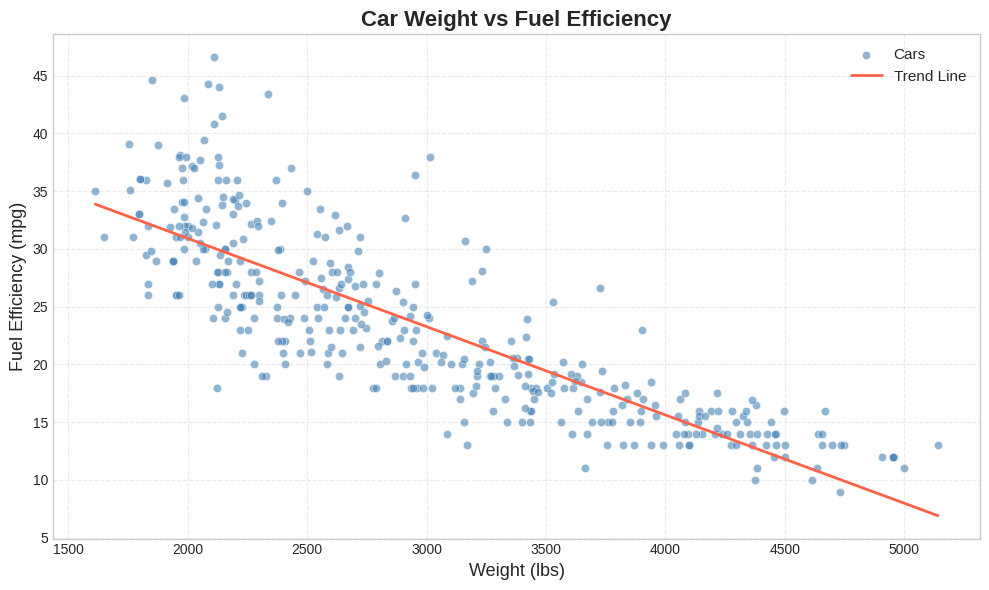

In [10]:
# TODO: Create a scatter plot of weight vs mpg
# Step 1: Create figure with plt.figure()
# Step 2: Create scatter plot with plt.scatter()
# Step 3: Add labels and title
# Step 4 (optional): Add trend line using np.polyfit()

plt.figure(figsize=(10, 6))

# Your code here
# Scatter plot
plt.scatter(df_clean['weight'], df_clean['mpg'], alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.5, label='Cars')

# Trend line
z = np.polyfit(df_clean['weight'], df_clean['mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['weight'].min(), df_clean['weight'].max(), 200)
plt.plot(x_line, p(x_line), color='tomato', linewidth=2, label='Trend Line')

# Labels and title
plt.title('Car Weight vs Fuel Efficiency', fontsize=16, fontweight='bold')
plt.xlabel('Weight (lbs)', fontsize=13)
plt.ylabel('Fuel Efficiency (mpg)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Task 2.2: Scatter Plot with Categories (10 points)

**TODO**: Create a scatter plot of **horsepower** vs **mpg**, colored by **origin** (USA, Europe, Japan).

Requirements:
- Different colors for each origin
- Add a legend
- Add appropriate title and labels

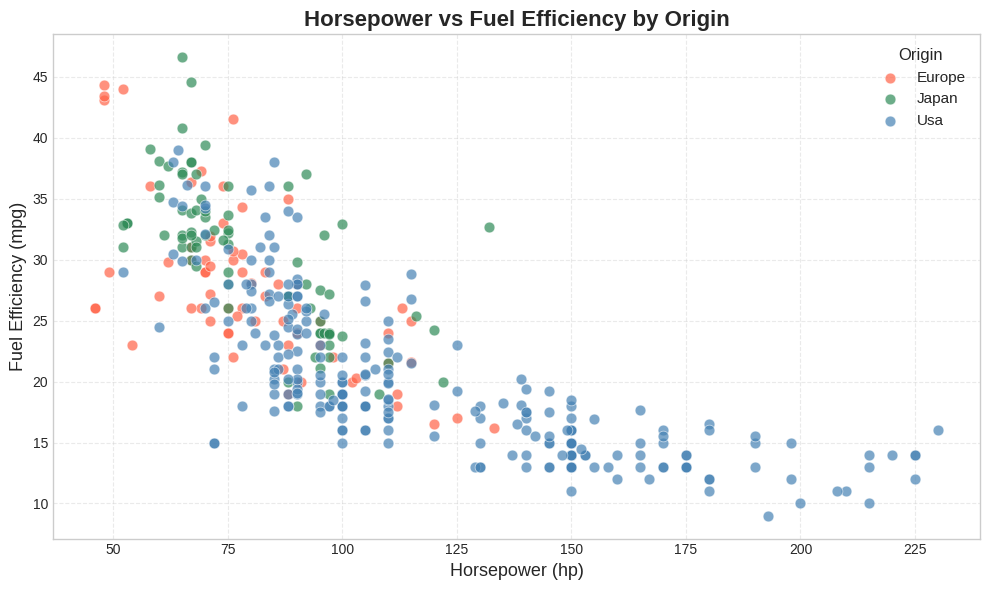

In [11]:
# TODO: Create a scatter plot colored by origin
# Hint: You'll need to use the original df (with 'origin' column)
# Use different colors for each origin group

plt.figure(figsize=(10, 6))

# Your code here
# You can use: for origin in df['origin'].unique(): plot each group
# Or use seaborn: sns.scatterplot(data=df, x='horsepower', y='mpg', hue='origin')
# Drop rows with missing horsepower before plotting
df_origin = df.dropna(subset=['horsepower'])
# Color map for each origin
colors = {'usa': 'steelblue', 'europe': 'tomato', 'japan': 'seagreen'}

for origin, group in df_origin.groupby('origin'):
    plt.scatter(group['horsepower'], group['mpg'],
                label=origin.capitalize(),
                color=colors[origin],
                alpha=0.7,
                edgecolors='white',
                linewidths=0.5,
                s=60)

# Labels and title
plt.title('Horsepower vs Fuel Efficiency by Origin', fontsize=16, fontweight='bold')
plt.xlabel('Horsepower (hp)', fontsize=13)
plt.ylabel('Fuel Efficiency (mpg)', fontsize=13)
plt.legend(title='Origin', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Task 2.3: Pair Plot (5 points)

**TODO**: Create a pair plot (scatter plot matrix) for the variables: `mpg`, `horsepower`, `weight`, and `acceleration`.

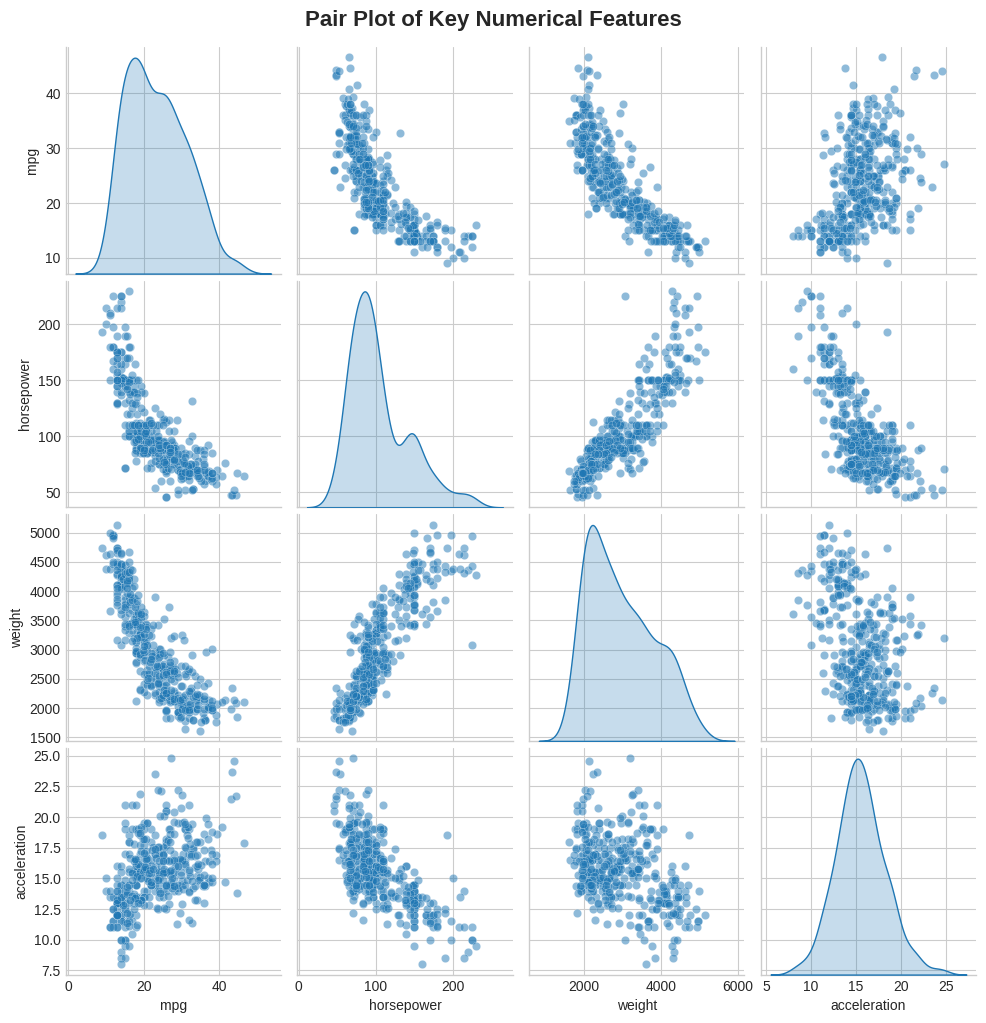

In [12]:
# TODO: Create a pair plot
# Hint: Use seaborn's pairplot function
# sns.pairplot(df_clean[['mpg', 'horsepower', 'weight', 'acceleration']])

# Your code here
sns.pairplot(df_clean[['mpg', 'horsepower', 'weight', 'acceleration']],
             diag_kind='kde',
             plot_kws={'alpha': 0.5, 'edgecolors': 'white', 'linewidths': 0.3},
             diag_kws={'fill': True})

plt.suptitle('Pair Plot of Key Numerical Features', fontsize=16, fontweight='bold', y=1.02)

plt.show()


---

## Part 3: Correlation Analysis (30 points)

Now let's quantify the relationships we observed visually.

### Task 3.1: Calculate Single Correlation (10 points)

**TODO**: Calculate the Pearson correlation coefficient between **weight** and **mpg**.

Use at least two methods:
1. NumPy's `np.corrcoef()`
2. SciPy's `stats.pearsonr()` (which also gives you the p-value)

In [13]:
# TODO: Calculate correlation between weight and mpg
# Method 1: np.corrcoef()
# Method 2: stats.pearsonr()

# Your code here
# Method 1: numpy
r_numpy = np.corrcoef(df_clean['weight'], df_clean['mpg'])[0, 1]

# Method 2: scipy
r_scipy, p_value = stats.pearsonr(df_clean['weight'], df_clean['mpg'])


# Print results with interpretation
# print(f"Correlation (numpy): {r_numpy:.4f}")
# print(f"Correlation (scipy): {r_scipy:.4f}")
# print(f"P-value: {p_value:.2e}")
# Print results with interpretation
print(f"Correlation (numpy):  {r_numpy:.4f}")
print(f"Correlation (scipy):  {r_scipy:.4f}")
print(f"P-value:              {p_value:.2e}")

# Interpretation
print("\nInterpretation:")
if abs(r_scipy) >= 0.7:
    strength = "strong"
elif abs(r_scipy) >= 0.4:
    strength = "moderate"
else:
    strength = "weak"

direction = "negative" if r_scipy < 0 else "positive"
print(f"There is a {strength} {direction} correlation (r = {r_scipy:.4f}) between weight and mpg.")
print(f"The result is {'statistically significant' if p_value < 0.05 else 'not statistically significant'} (p < 0.05)." )

Correlation (numpy):  -0.8322
Correlation (scipy):  -0.8322
P-value:              6.02e-102

Interpretation:
There is a strong negative correlation (r = -0.8322) between weight and mpg.
The result is statistically significant (p < 0.05).


### Task 3.2: Correlation Matrix (10 points)

**TODO**: Create a correlation matrix for all numerical variables and visualize it as a heatmap.

In [14]:
# TODO: Calculate the correlation matrix
# Hint: Use df_clean.corr()

# corr_matrix = ...
corr_matrix = df_clean.corr()

# Print the correlation matrix
print("Correlation Matrix:")
print(corr_matrix.round(3))


Correlation Matrix:
                mpg  cylinders  displacement  horsepower  weight  \
mpg           1.000     -0.778        -0.805      -0.778  -0.832   
cylinders    -0.778      1.000         0.951       0.843   0.898   
displacement -0.805      0.951         1.000       0.897   0.933   
horsepower   -0.778      0.843         0.897       1.000   0.865   
weight       -0.832      0.898         0.933       0.865   1.000   
acceleration  0.423     -0.505        -0.544      -0.689  -0.417   
model_year    0.581     -0.346        -0.370      -0.416  -0.309   

              acceleration  model_year  
mpg                  0.423       0.581  
cylinders           -0.505      -0.346  
displacement        -0.544      -0.370  
horsepower          -0.689      -0.416  
weight              -0.417      -0.309  
acceleration         1.000       0.290  
model_year           0.290       1.000  


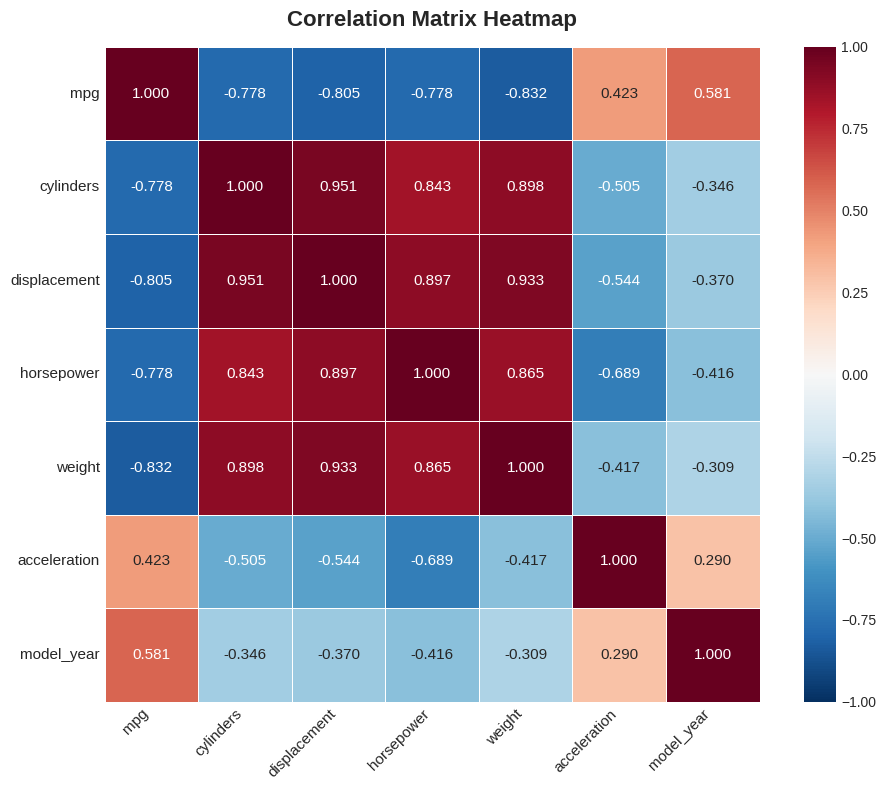

In [15]:
# TODO: Create a heatmap of the correlation matrix
# Hint: Use sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)

plt.figure(figsize=(10, 8))

# Your code here
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 11})

plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(fontsize=11, rotation=45, ha='right')
plt.yticks(fontsize=11, rotation=0)


plt.tight_layout()
plt.show()

### Task 3.3: Interpret the Correlations (10 points)

**TODO**: Based on the correlation matrix, answer the following questions in the markdown cell below:

1. Which variable has the **strongest positive correlation** with mpg?
2. Which variable has the **strongest negative correlation** with mpg?
3. Which two variables (other than mpg) have the **highest correlation** with each other?
4. Are there any surprising correlations? Explain.

**Your Answers:**

1. Strongest positive correlation with mpg: *model_year(r ≈ +0.581). Newer model years correlate with better fuel efficiency, reflecting advances in engine technology and tightening emissions regulations over time.*

2. Strongest negative correlation with mpg: *weight(r ≈ −0.832). This is the strongest relationship in the dataset — heavier cars consume significantly more fuel, which is physically intuitive.*

3. Highest correlation between other variables: *cylinders and displacement (r ≈ +0.951) have the highest correlation among non-mpg variables, because the number of cylinders is a direct determinant of engine displacement — it is essentially a near-physical law rather than a purely statistical trend.*

4. Surprising correlations: *acceleration vs horsepower (r ≈ −0.689) — this can seem counterintuitive at first. In this dataset, acceleration measures the time (in seconds) to go from 0 to 60 mph, so a higher value actually means slower. More horsepower → faster 0–60 → lower acceleration value, hence the negative correlation.
model_year vs mpg (r ≈ +0.581) — moderately strong and worth noting. It shows that fuel efficiency improved meaningfully across model years, likely driven by the 1973 oil crisis pushing manufacturers toward more efficient designs.*

---

## Part 4: Prediction Using Correlation (20 points)

Now let's use correlation to make predictions.

### Task 4.1: Implement Prediction Function (10 points)

**TODO**: Implement a function that predicts y from x using the formula:

$$\hat{y} = \bar{y} + r \frac{\sigma_y}{\sigma_x}(x - \bar{x})$$

Where:
- $r$ is the correlation coefficient
- $\bar{x}, \bar{y}$ are the means
- $\sigma_x, \sigma_y$ are the standard deviations

In [17]:
# TODO: Implement the prediction function
def predict_from_correlation(x_new, x_data, y_data):
    """
    Predict y from x using correlation.

    Parameters:
    - x_new: the new x value(s) to predict for
    - x_data: array of x values (training data)
    - y_data: array of y values (training data)

    Returns:
    - predicted y value(s)
    """
    # Calculate correlation
    r = np.corrcoef(x_data, y_data)[0, 1]

    # Calculate means
    x_mean = np.mean(x_data)
    y_mean = np.mean(y_data)

    # Calculate standard deviations
    x_std = np.std(x_data)
    y_std = np.std(y_data)

    # Calculate prediction
    y_pred = y_mean + r * (y_std / x_std) * (x_new - x_mean)

    return y_pred

# Test the function (uncomment after implementing)
test_pred = predict_from_correlation(3000, df_clean['weight'], df_clean['mpg'])
print(f"Predicted mpg for 3000 lbs car: {test_pred:.2f}")

Predicted mpg for 3000 lbs car: 23.27


### Task 4.2: Make Predictions (10 points)

**TODO**: Use your function to predict MPG for cars with the following weights:
- 2500 lbs
- 3000 lbs
- 3500 lbs
- 4000 lbs
- 4500 lbs

Then create a plot showing:
- The original scatter plot (weight vs mpg)
- The regression line with your predictions

In [18]:
# TODO: Make predictions for different weights
weights_to_predict = [2500, 3000, 3500, 4000, 4500]

# Your code here - make predictions
predictions = [predict_from_correlation(w, df_clean['weight'], df_clean['mpg'])
               for w in weights_to_predict]

# Print predictions
print("Weight (lbs) | Predicted MPG")
print("-" * 30)
for w, mpg in zip(weights_to_predict, predictions):
     print(f"{w:12} | {mpg:.2f}")

Weight (lbs) | Predicted MPG
------------------------------
        2500 | 27.10
        3000 | 23.27
        3500 | 19.45
        4000 | 15.63
        4500 | 11.80


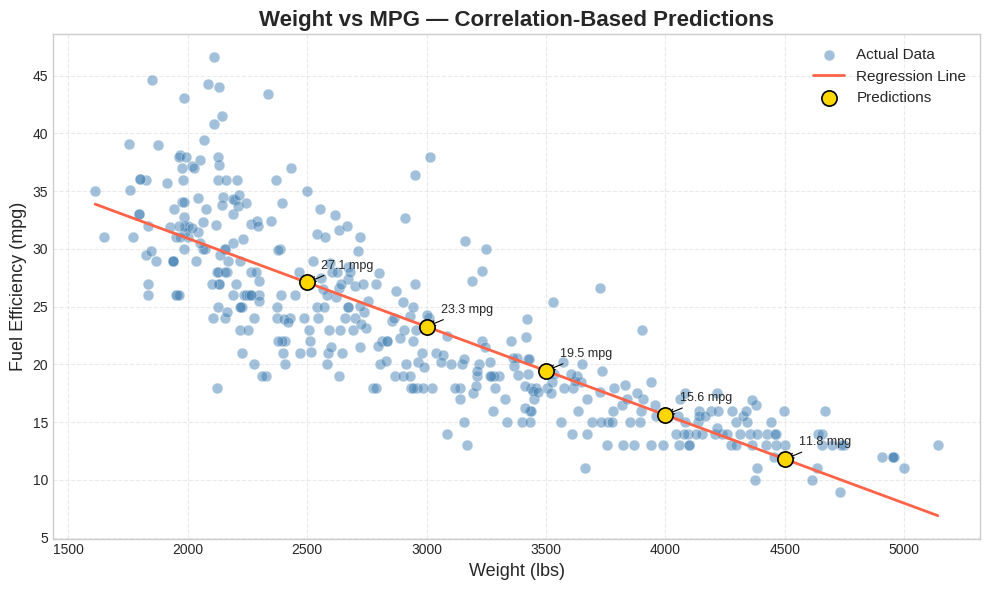

In [19]:
# TODO: Create a plot with scatter points and regression line
plt.figure(figsize=(10, 6))

# Step 1: Plot original data as scatter
plt.scatter(df_clean['weight'], df_clean['mpg'],
            alpha=0.5, color='steelblue', edgecolors='white',
            linewidths=0.4, s=60, label='Actual Data')

# Step 2: Plot regression line
x_line = np.linspace(df_clean['weight'].min(), df_clean['weight'].max(), 300)
y_line = predict_from_correlation(x_line, df_clean['weight'], df_clean['mpg'])
plt.plot(x_line, y_line, color='tomato', linewidth=2, label='Regression Line')

# Step 3: Mark the predicted points
plt.scatter(weights_to_predict, predictions,
            color='gold', edgecolors='black', linewidths=1.2,
            s=120, zorder=5, label='Predictions')

# Your code here
# Annotate each predicted point
for w, p in zip(weights_to_predict, predictions):
    plt.annotate(f'{p:.1f} mpg',
                 xy=(w, p),
                 xytext=(w + 60, p + 1.2),
                 fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

plt.title('Weight vs MPG — Correlation-Based Predictions', fontsize=16, fontweight='bold')
plt.xlabel('Weight (lbs)', fontsize=13)
plt.ylabel('Fuel Efficiency (mpg)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---

## Part 5: Correlation Pitfalls (15 points)

Understanding the limitations of correlation is crucial.

### Task 5.1: Non-linear Relationships (5 points)

**TODO**: The relationship between `acceleration` and `mpg` might not be perfectly linear. Create a scatter plot and calculate the correlation. Is correlation the best measure for this relationship?

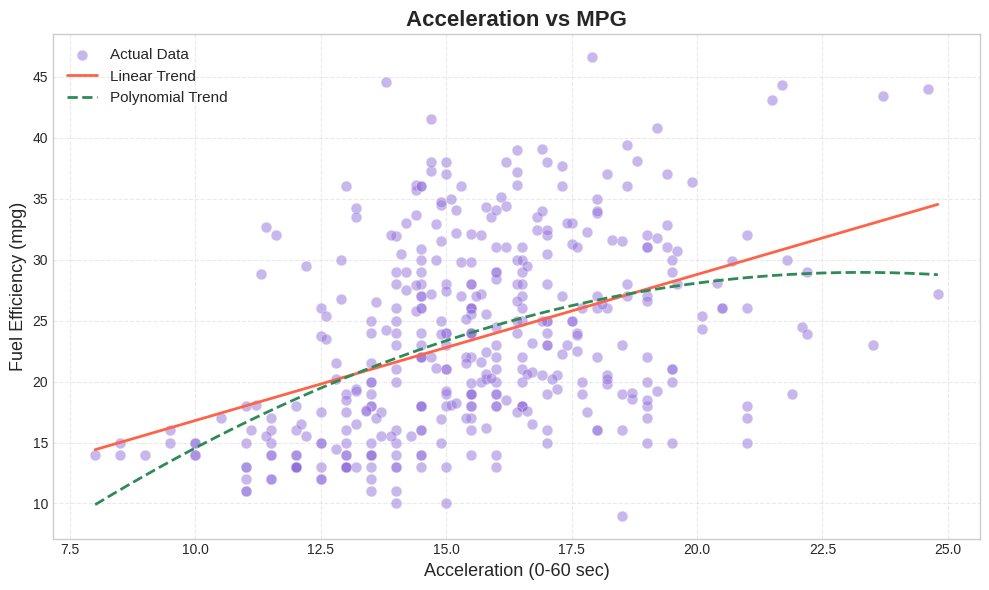

Correlation between acceleration and mpg: 0.423
P-value: 0.0000

Is correlation the best measure here?
  r = 0.423 suggests only a weak linear relationship.
  However, the polynomial trend fits the data noticeably better,
  indicating a non-linear relationship that Pearson r cannot capture.
  Conclusion: correlation alone is NOT sufficient for this relationship.


In [20]:
# TODO: Analyze the acceleration vs mpg relationship
# Create scatter plot and calculate correlation

plt.figure(figsize=(10, 6))

# Your code here
# Scatter plot
plt.scatter(df_clean['acceleration'], df_clean['mpg'],
            alpha=0.5, color='mediumpurple', edgecolors='white',
            linewidths=0.4, s=60, label='Actual Data')

# Linear trend line
z = np.polyfit(df_clean['acceleration'], df_clean['mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['acceleration'].min(), df_clean['acceleration'].max(), 200)
plt.plot(x_line, p(x_line), color='tomato', linewidth=2, label='Linear Trend')

# Polynomial trend line (degree 2)
z2 = np.polyfit(df_clean['acceleration'], df_clean['mpg'], 2)
p2 = np.poly1d(z2)
plt.plot(x_line, p2(x_line), color='seagreen', linewidth=2, linestyle='--', label='Polynomial Trend')

plt.title('Acceleration vs MPG', fontsize=16, fontweight='bold')
plt.xlabel('Acceleration (0-60 sec)', fontsize=13)
plt.ylabel('Fuel Efficiency (mpg)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Calculate and print correlation
# r_accel_mpg = ...
# print(f"Correlation between acceleration and mpg: {r_accel_mpg:.3f}")
r_accel_mpg, p_value = stats.pearsonr(df_clean['acceleration'], df_clean['mpg'])
print(f"Correlation between acceleration and mpg: {r_accel_mpg:.3f}")
print(f"P-value: {p_value:.4f}")
print()
print("Is correlation the best measure here?")
print(f"  r = {r_accel_mpg:.3f} suggests only a weak linear relationship.")
print("  However, the polynomial trend fits the data noticeably better,")
print("  indicating a non-linear relationship that Pearson r cannot capture.")
print("  Conclusion: correlation alone is NOT sufficient for this relationship.")

### Task 5.2: Correlation vs Causation (5 points)

**TODO**: Answer the following question in the markdown cell below:

We found a strong negative correlation between weight and mpg. Does this mean that:
- Making a car heavier **causes** it to have lower mpg?
- What are potential **confounding variables**?
- Can we conclude causation from this correlation?

**Your Answer:**

*1. Does making a car heavier cause lower mpg?
Not necessarily — at least not from correlation alone. While the relationship is physically plausible (heavier cars require more energy to move, thus burning more fuel), correlation only tells us two variables move together. It does not confirm that changing one directly causes a change in the other. Establishing causation requires controlled experiments or causal inference methods, not observational data alone.

2. Potential confounding variables:
Several hidden variables could be driving or distorting the weight–mpg relationship:

Engine size (displacement & cylinders) — larger engines are both heavier and less fuel-efficient. The car's weight may be a proxy for engine size rather than the direct cause of poor mpg.
Car type / body style — trucks and SUVs are heavier and less efficient by design; compact cars are lighter and more efficient. The category of car may be the true driver.
Aerodynamics — a heavy but aerodynamically optimised car may outperform a lighter but boxy one in fuel efficiency.
Drivetrain & transmission — all-wheel drive adds weight and reduces efficiency independently of total vehicle weight.
Era / model year — older cars tend to be heavier and less efficient due to older technology, so time period confounds both variables.


3. Can we conclude causation?
No. This dataset is observational — cars were not randomly assigned weights in a controlled experiment. The strong r ≈ −0.832 tells us weight and mpg are closely linked, but three alternative explanations always exist in observational data:

Reverse causation — manufacturers design fuel-efficient cars to be lighter, so the engineering intent drives both
Confounding — a third variable (e.g. engine size) independently affects both weight and mpg
Coincidence — unlikely here given the strength, but statistically possible


Bottom line: Correlation is evidence, not proof. The weight–mpg relationship is physically meaningful and worth investigating further, but confirming causation would require controlled testing — for example, taking the same car model and systematically varying its weight while holding all else constant.*


### Task 5.3: Pearson vs Spearman (5 points)

**TODO**: Calculate both Pearson and Spearman correlations for `horsepower` vs `mpg`. Which one is more appropriate and why?

In [21]:
# TODO: Calculate Pearson and Spearman correlations
# Hint: Use stats.pearsonr() and stats.spearmanr()

# Your code here
r_pearson,  p_pearson  = stats.pearsonr(df_clean['horsepower'], df_clean['mpg'])
r_spearman, p_spearman = stats.spearmanr(df_clean['horsepower'], df_clean['mpg'])

# print(f"Pearson correlation:  {r_pearson:.4f}")
# print(f"Spearman correlation: {r_spearman:.4f}")
print(f"Pearson correlation:  {r_pearson:.4f}  (p-value: {p_pearson:.2e})")
print(f"Spearman correlation: {r_spearman:.4f}  (p-value: {p_spearman:.2e})")

print()
print("Which is more appropriate?")
print()
print("  Pearson assumes a LINEAR relationship and is sensitive to outliers.")
print("  Spearman measures MONOTONIC relationships and is robust to outliers.")
print()
print("  For horsepower vs mpg:")
print("  - The relationship is curved (non-linear), not strictly linear.")
print("  - There are high-horsepower outliers that skew Pearson downward.")
print(f"  - Spearman ({r_spearman:.4f}) > Pearson ({r_pearson:.4f}) in absolute terms,")
print("    confirming the relationship is strongly monotonic but not purely linear.")
print()
print("  Conclusion: Spearman is more appropriate here.")



Pearson correlation:  -0.7784  (p-value: 7.03e-81)
Spearman correlation: -0.8536  (p-value: 1.62e-112)

Which is more appropriate?

  Pearson assumes a LINEAR relationship and is sensitive to outliers.
  Spearman measures MONOTONIC relationships and is robust to outliers.

  For horsepower vs mpg:
  - The relationship is curved (non-linear), not strictly linear.
  - There are high-horsepower outliers that skew Pearson downward.
  - Spearman (-0.8536) > Pearson (-0.7784) in absolute terms,
    confirming the relationship is strongly monotonic but not purely linear.

  Conclusion: Spearman is more appropriate here.


---

## Bonus Challenge (10 extra points)

For extra credit, complete the following challenge.

### Bonus: Multi-variable Analysis

**TODO**: Investigate whether the relationship between weight and mpg differs by origin (USA, Europe, Japan).

1. Calculate the correlation between weight and mpg **separately** for each origin
2. Create a visualization showing the different relationships
3. Explain your findings

In [22]:
# BONUS: Analyze weight-mpg correlation by origin
# Calculate correlations for each origin group

# Your code here
colors = {'usa': 'steelblue', 'europe': 'tomato', 'japan': 'seagreen'}

# Step 1: Calculate correlations per origin
print("Correlation between Weight and MPG by Origin:")
print("-" * 50)
for origin in df['origin'].unique():
    group = df[df['origin'] == origin].dropna(subset=['weight', 'mpg'])
    r, p = stats.pearsonr(group['weight'], group['mpg'])
    print(f"  {origin.capitalize():10} | r = {r:.4f} | p-value = {p:.2e}")


Correlation between Weight and MPG by Origin:
--------------------------------------------------
  Usa        | r = -0.8464 | p-value = 1.90e-68
  Japan      | r = -0.5641 | p-value = 6.17e-08
  Europe     | r = -0.5120 | p-value = 8.08e-06


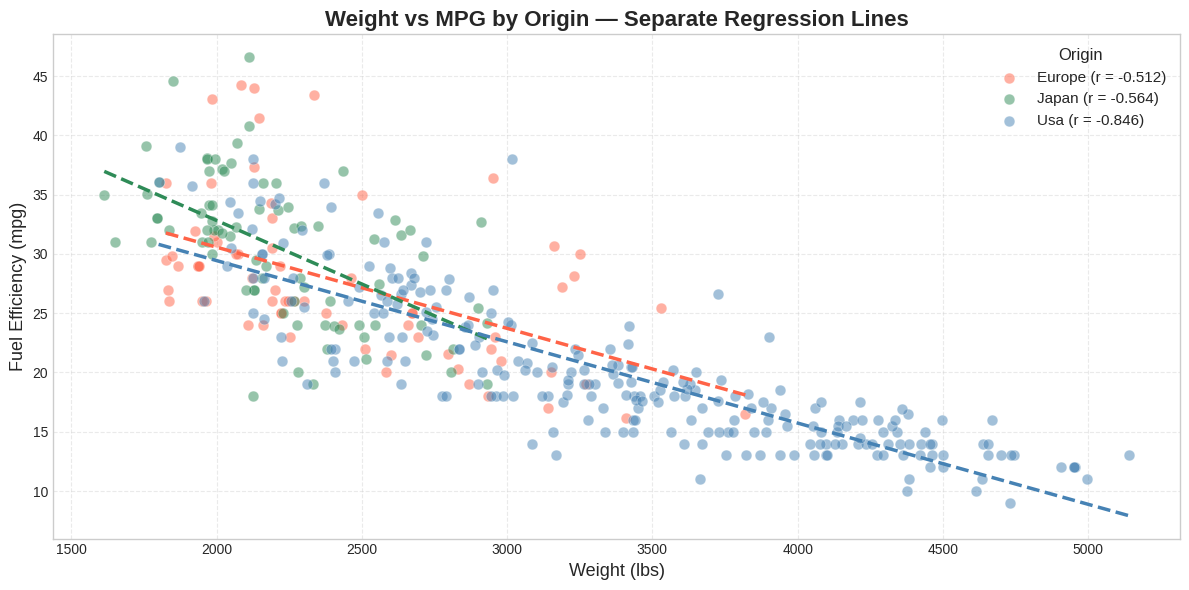

In [23]:
# BONUS: Create visualization with separate regression lines for each origin

plt.figure(figsize=(12, 6))

# Your code here
colors = {'usa': 'steelblue', 'europe': 'tomato', 'japan': 'seagreen'}

for origin, group in df.dropna(subset=['weight', 'mpg']).groupby('origin'):
    r, _ = stats.pearsonr(group['weight'], group['mpg'])

    # Scatter points
    plt.scatter(group['weight'], group['mpg'],
                alpha=0.5, color=colors[origin], edgecolors='white',
                linewidths=0.4, s=60, label=f'{origin.capitalize()} (r = {r:.3f})')

    # Regression line
    z = np.polyfit(group['weight'], group['mpg'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(group['weight'].min(), group['weight'].max(), 200)
    plt.plot(x_line, p(x_line), color=colors[origin], linewidth=2.5, linestyle='--')

plt.title('Weight vs MPG by Origin — Separate Regression Lines', fontsize=16, fontweight='bold')
plt.xlabel('Weight (lbs)', fontsize=13)
plt.ylabel('Fuel Efficiency (mpg)', fontsize=13)
plt.legend(fontsize=11, title='Origin', title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Bonus Question:

What do the different correlations by origin tell us? Is the weight-mpg relationship consistent across all origins, or are there differences?

**Your Answer:**

*Thanks for sharing! Here's the updated interpretation based on your actual values:

USA (r ≈ −0.846) — strongest by far. Weight is a dominant predictor for American cars, which span a very wide weight range.

Japan (r ≈ −0.564) — moderate. Japanese cars cluster in a narrow, lighter weight band, so weight explains less of the mpg variation.

Europe (r ≈ −0.512) — weakest. Other factors (engine type, aerodynamics) play a bigger role beyond just weight.

Conclusion: The negative relationship holds universally, but weight is a much stronger predictor for US cars than for Japanese or European ones. The pooled r ≈ −0.832 is heavily influenced by the USA group, which dominates the dataset numerically — a clear example of why segmenting data matters.*


---

## Submission Checklist

Before submitting, make sure you have:

- [ ] Completed all TODO tasks
- [ ] Run all cells from top to bottom without errors
- [ ] Added titles and labels to all visualizations
- [ ] Written answers to all analysis questions
- [ ] Saved your notebook

**Total Points: 100 (+ 10 bonus)**

| Section | Points |
|---------|--------|
| Part 1: Loading and Exploring | 10 |
| Part 2: Scatter Plots | 25 |
| Part 3: Correlation Analysis | 30 |
| Part 4: Prediction | 20 |
| Part 5: Correlation Pitfalls | 15 |
| Bonus | 10 |

---

**Good luck!** 🎉